# SAR Target Classification
### Drone / Bird / Floating Tree / Balloon


### 1. Mount Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os

# All files will be saved here in your Google Drive
BASE_DIR    = '/content/drive/MyDrive/SAR_Project'
DATASET_DIR = os.path.join(BASE_DIR, 'sar1_dataset')
SAVE_DIR    = BASE_DIR

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,    exist_ok=True)

print('Drive mounted!')
print(f'Dataset will be saved to: {DATASET_DIR}')

Mounted at /content/drive
Drive mounted!
Dataset will be saved to: /content/drive/MyDrive/SAR_Project/sar1_dataset


### 2. Install libraries

In [11]:
!pip install -q torch torchvision seaborn

### 3. SAR Radar Parameters

In [12]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ── Radar parameters ──
c   = 3e8
fc  = 9.6e9
lam = c / fc
B   = 400e6
Tp  = 20e-6
fs  = 600e6
prf = 2000
v   = 120
h   = 5000

num_pulses = 512
num_fast   = int(fs * Tp)

SAR_VMIN_DB = -40
SAR_VMAX_DB =  20
EPSILON     = 1e-6

# ── Time axes ──
t_fast = np.linspace(-Tp/2, Tp/2, num_fast)
t_slow = np.arange(num_pulses) / prf

# ── Chirp ──
def chirp(t):
    k = B / Tp
    return np.exp(1j * 2*np.pi * (fc*t + 0.5*k*t**2))

tx_chirp = chirp(t_fast)

# ── Platform ──
platform_y = v * t_slow
platform_x = np.zeros_like(platform_y)
platform_z = h

# ── Filters (computed once) ──
H_r   = np.conj(np.fft.fft(tx_chirp))
R_ref = np.mean(np.sqrt(platform_y**2 + h**2))
Ka    = -2 * v**2 / (lam * R_ref)
fa    = np.fft.fftshift(np.fft.fftfreq(num_pulses, d=1/prf))
H_az  = np.exp(1j * np.pi * fa**2 / Ka)

print('Radar parameters set!')
print(f'num_fast = {num_fast}  |  num_pulses = {num_pulses}')

Radar parameters set!
num_fast = 12000  |  num_pulses = 512


### 4. Trajectory Functions

In [13]:
def trajectory_tree(t):
    x0  = np.random.uniform(-500, 500)
    y0  = np.random.uniform(800, 1500)
    x   = x0 + np.random.normal(0, 0.03, size=len(t))
    y   = y0 + np.random.normal(0, 0.03, size=len(t))
    z   = np.zeros_like(t)
    rcs = np.full_like(t, 1.0)
    return x, y, z, rcs

def trajectory_balloon(t):
    x0  = np.random.uniform(-500, 500)
    y0  = np.random.uniform(800, 1500)
    z0  = np.random.uniform(50, 150)
    vx  = np.random.uniform(0.2, 1.0)
    vy  = np.random.uniform(0.5, 1.5)
    vz  = np.random.uniform(0.0, 0.3)
    x   = x0 + vx * t
    y   = y0 + vy * t
    z   = z0 + vz * t
    rcs = np.full_like(t, np.random.uniform(0.6, 1.0))
    return x, y, z, rcs

def trajectory_bird(t):
    x0  = np.random.uniform(-500, 500)
    y0  = np.random.uniform(800, 1500)
    z0  = np.random.uniform(10, 50)
    vy  = np.random.uniform(8, 15)
    Ax  = np.random.uniform(1, 5)
    fx  = np.random.uniform(1, 3)
    Az  = np.random.uniform(1, 3)
    fz  = np.random.uniform(3, 8)
    x   = x0 + Ax * np.sin(2*np.pi*fx*t) + np.random.normal(0, 1.0, len(t))
    y   = y0 + vy * t                     + np.random.normal(0, 1.5, len(t))
    z   = z0 + Az * np.sin(2*np.pi*fz*t)
    rcs = np.random.uniform(0.2, 0.5, size=len(t))
    return x, y, z, rcs

def trajectory_drone(t):
    x0  = np.random.uniform(-500, 500)
    y0  = np.random.uniform(800, 1500)
    z0  = np.random.uniform(20, 80)
    vy  = np.random.uniform(3, 6)
    Az  = np.random.uniform(0.05, 0.2)
    fr  = np.random.uniform(20, 80)
    x   = np.full_like(t, x0)
    y   = y0 + vy * t
    z   = z0 + Az * np.sin(2*np.pi*fr*t)
    rcs = np.full_like(t, np.random.uniform(0.4, 0.8))
    return x, y, z, rcs

def get_trajectory(label, t):
    if label == 'floating_tree': return trajectory_tree(t)
    if label == 'balloon':       return trajectory_balloon(t)
    if label == 'bird':          return trajectory_bird(t)
    if label == 'drone':         return trajectory_drone(t)
    raise ValueError(f'Unknown label: {label}')

print('Trajectory functions ready!')

Trajectory functions ready!


### 5. SAR Image Generator

In [14]:
def generate_sar_image(label):
    x, y, z, rcs = get_trajectory(label, t_slow)

    raw = np.zeros((num_pulses, num_fast), dtype=np.complex64)
    for i in range(num_pulses):
        R          = np.sqrt((platform_x[i]-x[i])**2 +
                             (platform_y[i]-y[i])**2 +
                             (platform_z  -z[i])**2)
        tau        = 2 * R / c
        raw[i, :]  = rcs[i] * chirp(t_fast - tau)

    range_comp = np.fft.ifft(np.fft.fft(raw, axis=1) * H_r, axis=1)
    az_fft     = np.fft.fftshift(np.fft.fft(range_comp, axis=0), axes=0)
    focused    = np.fft.ifft(
                     np.fft.ifftshift(az_fft * H_az[:, np.newaxis], axes=0), axis=0)

    SNR_dB       = np.random.uniform(10, 25)
    SNR          = 10 ** (SNR_dB / 10)
    signal_power = np.mean(np.abs(focused)**2)
    noise_power  = signal_power / SNR
    noise        = np.sqrt(noise_power/2) * (
                       np.random.randn(*focused.shape) +
                       1j*np.random.randn(*focused.shape))
    focused     += noise

    speckle = np.random.gamma(1, 1, size=focused.shape)
    sar     = np.abs(focused)**2 * speckle
    sar_db  = 10 * np.log10(sar + EPSILON)
    return sar_db

print('SAR image generator ready!')

SAR image generator ready!


### 6. Generate Dataset (saves directly to Google Drive)


In [15]:
from PIL import Image as PILImage

LABELS               = ['floating_tree', 'balloon', 'bird', 'drone']
NUM_IMAGES_PER_CLASS = 1
IMG_SIZE             = 224

counter = 0
for lbl in LABELS:
    print(f'Generating {NUM_IMAGES_PER_CLASS} images for: {lbl} ...')
    for i in range(NUM_IMAGES_PER_CLASS):
        sar_img = generate_sar_image(lbl)

        # Normalize to 0-255
        arr = np.clip(sar_img, SAR_VMIN_DB, SAR_VMAX_DB)
        arr = (arr - SAR_VMIN_DB) / (SAR_VMAX_DB - SAR_VMIN_DB)
        arr_uint8 = (arr * 255).astype(np.uint8)

        # Resize and save as PNG
        img = PILImage.fromarray(arr_uint8)
        img = img.resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
        filename = f'{lbl}_{counter}.png'
        img.save(os.path.join(DATASET_DIR, filename))
        counter += 1

    print(f'  Done! {counter} images saved so far.')

print(f'\nDataset complete! {counter} images saved to Google Drive.')
print(f'Approximate size: {counter * 50 / 1000:.1f} MB')

Generating 1 images for: floating_tree ...
  Done! 1 images saved so far.
Generating 1 images for: balloon ...
  Done! 2 images saved so far.
Generating 1 images for: bird ...
  Done! 3 images saved so far.
Generating 1 images for: drone ...
  Done! 4 images saved so far.

Dataset complete! 4 images saved to Google Drive.
Approximate size: 0.2 MB


### 7. Preview one image (just to verify)

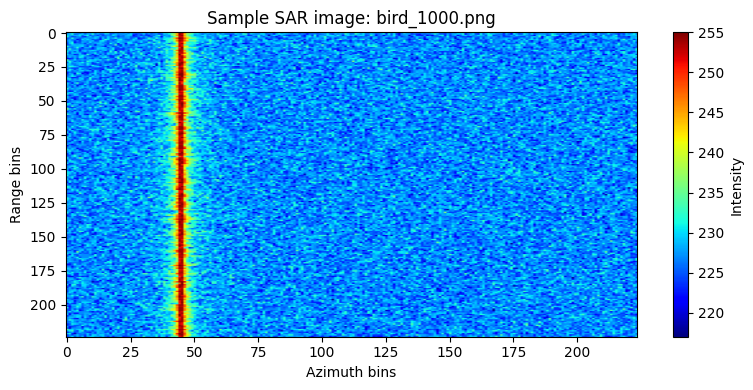

Image shape: (224, 224)


In [16]:
import matplotlib
matplotlib.use('inline')
from PIL import Image as PILImage

sample_file = [f for f in os.listdir(DATASET_DIR) if f.endswith('.png')][0]
sample_img  = np.array(PILImage.open(os.path.join(DATASET_DIR, sample_file)))

plt.figure(figsize=(8, 4))
plt.imshow(sample_img, cmap='jet', aspect='auto')
plt.colorbar(label='Intensity')
plt.title(f'Sample SAR image: {sample_file}')
plt.xlabel('Azimuth bins')
plt.ylabel('Range bins')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_sar.png'))
plt.show()
print(f'Image shape: {sample_img.shape}')

### 8. Import Libraries for Training

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found — make sure you enabled T4 GPU in Runtime settings!')

Using device: cuda
GPU: Tesla T4


### 9. Dataset Class

In [18]:
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IMG_SIZE  = 224

class SARDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels     = labels
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load PNG directly
        img = PILImage.open(self.file_paths[idx]).convert('L')  # grayscale
        arr = np.array(img).astype(np.float32) / 255.0

        # 3 channel tensor
        tensor = torch.from_numpy(arr).unsqueeze(0).repeat(3, 1, 1)

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, self.labels[idx]

print('Dataset class ready!')

Dataset class ready!


### 10. Load Files and Split into Train / Val / Test

In [19]:
files, label_ids = [], []
for fname in sorted(os.listdir(DATASET_DIR)):
    if not fname.endswith('.png'):   # ← changed from .npy to .png
        continue
    for lbl in LABELS:
        if fname.startswith(lbl + '_'):
            files.append(os.path.join(DATASET_DIR, fname))
            label_ids.append(LABEL2IDX[lbl])
            break

print(f'Total images found: {len(files)}')
for lbl, idx in LABEL2IDX.items():
    print(f'  {lbl:<15}: {label_ids.count(idx)} images')

X_train, X_tmp, y_train, y_tmp = train_test_split(
    files, label_ids, test_size=0.30, stratify=label_ids, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Total images found: 2003
  floating_tree  : 500 images
  balloon        : 501 images
  bird           : 501 images
  drone          : 501 images

Train: 1402 | Val: 300 | Test: 301


### 11. Build ResNet-50 Model

In [20]:
# Augmentations
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])
eval_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])
BATCH_SIZE = 32
train_loader = DataLoader(SARDataset(X_train, y_train, train_transform), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(SARDataset(X_val,   y_val,   eval_transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(SARDataset(X_test,  y_test,  eval_transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
# ResNet-50 model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, len(LABELS))
)
model = model.to(DEVICE)
print('ResNet-50 model built!')
print(f'Output classes: {len(LABELS)} — {LABELS}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 101MB/s] 


ResNet-50 model built!
Output classes: 4 — ['floating_tree', 'balloon', 'bird', 'drone']


### 12. Train the Model
### This will take 3-5 minutes on GPU

In [21]:
NUM_EPOCHS   = 30
LR           = 3e-4
PATIENCE     = 8
MODEL_PATH   = os.path.join(SAVE_DIR, 'sar_best_model.pth')

# Class weights for imbalance
counts       = np.bincount(y_train, minlength=len(LABELS)).astype(np.float32)
class_weights = torch.tensor(1.0 / (counts + 1e-6)).to(DEVICE)
class_weights /= class_weights.sum()
criterion    = nn.CrossEntropyLoss(weight=class_weights)
optimizer    = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_acc  = 0.0
patience_cnt  = 0
train_accs, val_accs, train_losses, val_losses = [], [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += (out.argmax(1) == lbls).sum().item()
        t_total   += imgs.size(0)

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out   = model(imgs)
            loss  = criterion(out, lbls)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total   += imgs.size(0)

    tr_acc = t_correct / t_total
    vl_acc = v_correct / v_total
    tr_loss = t_loss / t_total
    vl_loss = v_loss / v_total

    train_accs.append(tr_acc);    val_accs.append(vl_acc)
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    scheduler.step()

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train acc: {tr_acc:.3f} loss: {tr_loss:.4f} | '
          f'Val acc: {vl_acc:.3f} loss: {vl_loss:.4f}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'           ✓ Best model saved! val_acc = {best_val_acc:.3f}')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining complete! Best val accuracy: {best_val_acc:.3f}')

Epoch  1/30 | Train acc: 0.719 loss: 0.7223 | Val acc: 0.753 loss: 0.5188
           ✓ Best model saved! val_acc = 0.753
Epoch  2/30 | Train acc: 0.911 loss: 0.2376 | Val acc: 0.780 loss: 0.5614
           ✓ Best model saved! val_acc = 0.780
Epoch  3/30 | Train acc: 0.947 loss: 0.1515 | Val acc: 0.950 loss: 0.1596
           ✓ Best model saved! val_acc = 0.950
Epoch  4/30 | Train acc: 0.954 loss: 0.1297 | Val acc: 0.920 loss: 0.3465
Epoch  5/30 | Train acc: 0.979 loss: 0.0759 | Val acc: 0.990 loss: 0.0613
           ✓ Best model saved! val_acc = 0.990
Epoch  6/30 | Train acc: 0.978 loss: 0.0610 | Val acc: 0.890 loss: 0.3076
Epoch  7/30 | Train acc: 0.985 loss: 0.0464 | Val acc: 0.987 loss: 0.0329
Epoch  8/30 | Train acc: 0.989 loss: 0.0359 | Val acc: 0.980 loss: 0.0458
Epoch  9/30 | Train acc: 0.993 loss: 0.0273 | Val acc: 0.987 loss: 0.0382
Epoch 10/30 | Train acc: 0.989 loss: 0.0407 | Val acc: 0.987 loss: 0.0923
Epoch 11/30 | Train acc: 0.964 loss: 0.1652 | Val acc: 0.677 loss: 1.858

### 13. Plot Training History

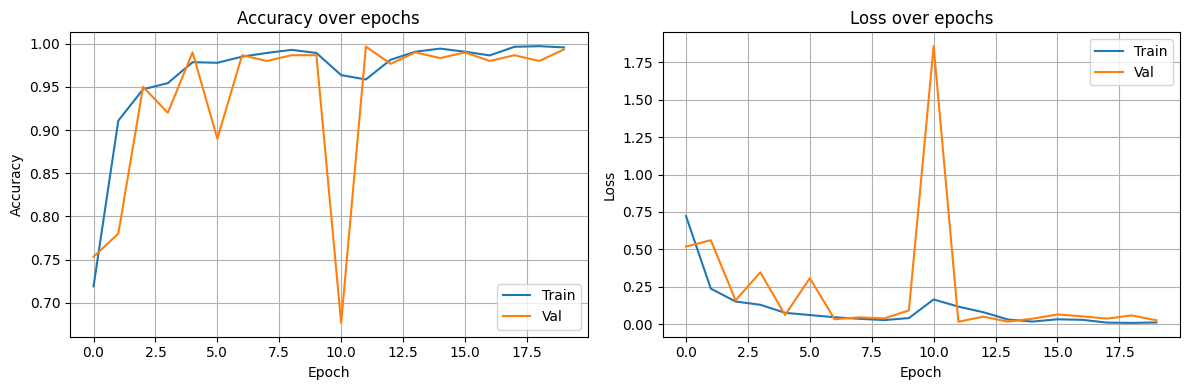

Training history saved to Google Drive!


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_accs, label='Train')
axes[0].plot(val_accs,   label='Val')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid()

axes[1].plot(train_losses, label='Train')
axes[1].plot(val_losses,   label='Val')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'))
plt.show()
print('Training history saved to Google Drive!')

### 14. Test Accuracy + Confusion Matrix

=== TEST RESULTS ===
               precision    recall  f1-score   support

floating_tree       0.99      1.00      0.99        75
      balloon       1.00      1.00      1.00        75
         bird       0.99      0.97      0.98        75
        drone       0.97      0.97      0.97        76

     accuracy                           0.99       301
    macro avg       0.99      0.99      0.99       301
 weighted avg       0.99      0.99      0.99       301



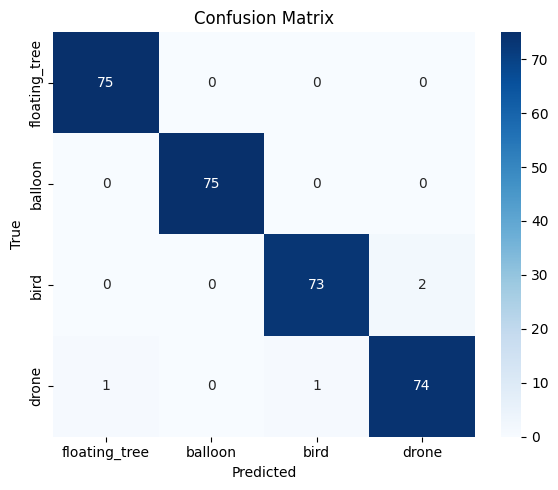

Confusion matrix saved to Google Drive!


In [23]:
# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(lbls.numpy())

print('=== TEST RESULTS ===')
print(classification_report(all_true, all_preds, target_names=LABELS))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'))
plt.show()
print('Confusion matrix saved to Google Drive!')